# SE4095 — Social Network Theory and Practice
# Assignment #01 — Political Blogs Network Analysis

**Student:** Ahmad
**Dataset:** `polblogs.gml` (Adamic & Glance, 2005 — Political Blogosphere network)

This notebook is runnable top-to-bottom. Each Part is a separate section:
the **reasoning/justification is explained first in a markdown cell**,
followed by its **implementation in a code cell**.

**Global setting:** Random seed = 42 is used consistently throughout the
notebook wherever randomness is involved (e.g. node selection in the
random-removal experiment). For community detection in Part D, 5 separate
seeds (0–4) are used, as required for stochastic methods.


In [1]:
# ---- Imports & global setup ----
import os
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from itertools import combinations
import community as community_louvain  # pip install python-louvain

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

DATA_PATH = "data/polblogs.gml"   # <-- relative path; place your downloaded polblogs.gml here
print("Setup done. Looking for dataset at:", DATA_PATH)


Setup done. Looking for dataset at: data/polblogs.gml


---
## Part A — Dataset and Graph Construction (15 marks)

### Reasoning / Justification

**1. Loading the data:** `polblogs.gml` is a GML file in which each
node's `value` attribute stores its political-orientation ground-truth
label (0 = liberal, 1 = conservative). At this stage this label is only
**preserved** — it is not used in any calculation yet (Core Rule: labels
are used only in Part E).

**2. Identifying graph representation:**
- **Directed vs Undirected** → A hyperlink means "blog A links to blog
  B" — this is an ASYMMETRIC relationship (A→B does not imply B→A).
  Therefore a **DIRECTED** representation correctly matches the data.
- **Weighted vs Unweighted** → The GML file has no edge-weight
  attribute, only the presence of a hyperlink. Therefore **UNWEIGHTED**.
- **Simple vs Multigraph** → We count the raw `edge [...]` blocks in the
  file and compare against the networkx-loaded edge count. If they match,
  no duplicate/parallel edges existed in the source data.

**3. Preprocessing decisions (each justified):**
- **Remove self-loops:** A blog linking to itself is meaningless for
  "brokerage" or "authority toward others" — it distorts PageRank and
  Betweenness scores.
- **Duplicate edges:** networkx's `read_gml()` loads a simple DiGraph, so
  parallel edges would have been collapsed automatically at load time if
  they existed — we verify via raw-vs-loaded edge counts whether any
  actually did.
- **Remove isolates:** Nodes with in-degree = 0 AND out-degree = 0 always
  score 0 on every centrality measure and cannot meaningfully belong to
  any community.
- **Disconnected components:** The political-blogs network contains many
  small disconnected clusters. Distance-based centrality (Closeness,
  Betweenness) is not well-defined on a disconnected graph (unreachable
  pairs have infinite distance). **Solution:** restrict the analysis
  graph to the **Largest Weakly Connected Component (LWCC)**.
  - **Direction convention = WEAK connectivity** (rather than strong),
    because strong connectivity (SCC) is far too restrictive for
    hyperlink graphs — using SCC would exclude many valid, important
    nodes from the analysis. Weak connectivity is standard practice in
    the literature for this dataset.

**Required evidence produced:** data dictionary, preprocessing log,
degree-distribution figure, network visualization, and a short
interpretation.


In [2]:
# ---- A.1: Load raw graph ----
G_raw = nx.read_gml(DATA_PATH)

print("Type:", type(G_raw).__name__)
print("Nodes:", G_raw.number_of_nodes())
print("Edges:", G_raw.number_of_edges())
print("Sample node with attributes:", list(G_raw.nodes(data=True))[0])


Type: DiGraph
Nodes: 1490
Edges: 19016
Sample node with attributes: ('100monkeystyping.com', {'value': 0, 'source': 'Blogarama'})


In [3]:
# ---- A.2: Identify representation (directed/weighted/simple?) ----
with open(DATA_PATH, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

raw_edge_blocks = raw_text.count("\n  edge [")
raw_node_blocks = raw_text.count("\n  node [")
declared_directed = "directed 1" in raw_text
has_weight_attr = any("weight" in d for _, _, d in G_raw.edges(data=True))

representation_info = {
    "declared_directed_in_gml_file": declared_directed,
    "networkx_is_directed": G_raw.is_directed(),
    "networkx_is_multigraph": G_raw.is_multigraph(),
    "raw_node_blocks_in_file": raw_node_blocks,
    "raw_edge_blocks_in_file": raw_edge_blocks,
    "networkx_loaded_edges": G_raw.number_of_edges(),
    "duplicate_edges_detected (raw_blocks - loaded)": raw_edge_blocks - G_raw.number_of_edges(),
    "has_weight_attribute": has_weight_attr,
}
pd.Series(representation_info)


declared_directed_in_gml_file                      True
networkx_is_directed                               True
networkx_is_multigraph                            False
raw_node_blocks_in_file                            1490
raw_edge_blocks_in_file                           19016
networkx_loaded_edges                             19016
duplicate_edges_detected (raw_blocks - loaded)        0
has_weight_attribute                              False
dtype: object

**Interpretation:** `raw_edge_blocks_in_file` == `networkx_loaded_edges`
→ this means no duplicate hyperlink edges existed in the original file
(if they had, the loaded count would be lower). Graph confirmed:
**Directed, Unweighted, Simple** (no collapsing occurred at load time).

In [4]:
# ---- A.3: Data dictionary ----
data_dictionary = pd.DataFrame([
    ("Node ID", "internal identifier", "Blog's domain/URL string, e.g. '100monkeystyping.com'"),
    ("value", "political-orientation label (GROUND TRUTH)", "0 = liberal/left blog, 1 = conservative/right blog. Used ONLY in Part E."),
    ("source", "directory source", "Which blog directory listed this blog (e.g. Blogarama) — not used analytically."),
    ("Edge (u -> v)", "hyperlink", "Blog u links to blog v on its front page. Directed, unweighted, no self-relation implied."),
], columns=["Field", "Meaning", "Description"])

data_dictionary.to_csv("outputs/tables/data_dictionary.csv", index=False)
data_dictionary


,Field,Meaning,Description
0,Node ID,internal identifier,"Blog's domain/URL string, e.g. '100monkeystypi..."
1,value,political-orientation label (GROUND TRUTH),"0 = liberal/left blog, 1 = conservative/right ..."
2,source,directory source,Which blog directory listed this blog (e.g. Bl...
3,Edge (u -> v),hyperlink,Blog u links to blog v on its front page. Dire...


In [5]:
# ---- A.4: Preprocessing / cleaning ----
log = {}
log["before_nodes"] = G_raw.number_of_nodes()
log["before_edges"] = G_raw.number_of_edges()

# (a) remove self-loops
G1 = G_raw.copy()
self_loops = list(nx.selfloop_edges(G1))
G1.remove_edges_from(self_loops)
log["self_loops_removed"] = len(self_loops)

# (b) duplicate edges — none found (verified above), logged for transparency
log["duplicate_edges_removed"] = 0

# (c) remove isolates (in-degree=0 AND out-degree=0)
isolates = list(nx.isolates(G1))
G_clean_full = G1.copy()
G_clean_full.remove_nodes_from(isolates)
log["isolates_removed"] = len(isolates)
log["after_full_clean_nodes"] = G_clean_full.number_of_nodes()
log["after_full_clean_edges"] = G_clean_full.number_of_edges()

# (d) restrict analysis graph to the Largest Weakly Connected Component (LWCC)
wccs = list(nx.weakly_connected_components(G_clean_full))
log["num_weakly_connected_components"] = len(wccs)
largest_wcc_nodes = max(wccs, key=len)
log["largest_wcc_size"] = len(largest_wcc_nodes)
log["nodes_dropped_as_small_disconnected_components"] = G_clean_full.number_of_nodes() - len(largest_wcc_nodes)

G_analysis = G_clean_full.subgraph(largest_wcc_nodes).copy()
log["analysis_graph_nodes"] = G_analysis.number_of_nodes()
log["analysis_graph_edges"] = G_analysis.number_of_edges()

pd.Series(log).to_csv("outputs/tables/preprocessing_log.csv")
pd.Series(log)


before_nodes                                       1490
before_edges                                      19016
self_loops_removed                                    2
duplicate_edges_removed                               0
isolates_removed                                    266
after_full_clean_nodes                             1224
after_full_clean_edges                            19014
num_weakly_connected_components                       2
largest_wcc_size                                   1222
nodes_dropped_as_small_disconnected_components        2
analysis_graph_nodes                               1222
analysis_graph_edges                              19013
dtype: int64

**Note (naming convention used throughout this notebook):**
- `G_raw` = as loaded from file
- `G_clean_full` = self-loops + isolates removed (still has small disconnected pieces)
- `G_analysis` = `G_clean_full`'s **largest weakly connected component only** —
  **iske aage Part B, C, D, E ki saari calculations isi graph par hongi.**


In [6]:
# ---- A.5: Graph statistics on the ANALYSIS graph ----
n = G_analysis.number_of_nodes()
e = G_analysis.number_of_edges()
density = nx.density(G_analysis)

wcc = list(nx.weakly_connected_components(G_analysis))
scc = list(nx.strongly_connected_components(G_analysis))

in_degrees = [d for _, d in G_analysis.in_degree()]
out_degrees = [d for _, d in G_analysis.out_degree()]

graph_stats = {
    "nodes": n, "edges": e, "density": density,
    "num_weakly_connected_components": len(wcc),
    "largest_wcc_size": max(len(c) for c in wcc),
    "num_strongly_connected_components": len(scc),
    "largest_scc_size": max(len(c) for c in scc),
    "in_degree_mean": np.mean(in_degrees), "in_degree_median": np.median(in_degrees), "in_degree_max": np.max(in_degrees),
    "out_degree_mean": np.mean(out_degrees), "out_degree_median": np.median(out_degrees), "out_degree_max": np.max(out_degrees),
}
pd.Series(graph_stats).to_csv("outputs/tables/graph_statistics.csv")
pd.Series(graph_stats)


nodes                                 1222.000000
edges                                19013.000000
density                                  0.012743
num_weakly_connected_components          1.000000
largest_wcc_size                      1222.000000
num_strongly_connected_components      420.000000
largest_scc_size                       793.000000
in_degree_mean                          15.558920
in_degree_median                         3.000000
in_degree_max                          337.000000
out_degree_mean                         15.558920
out_degree_median                        7.000000
out_degree_max                         256.000000
dtype: float64

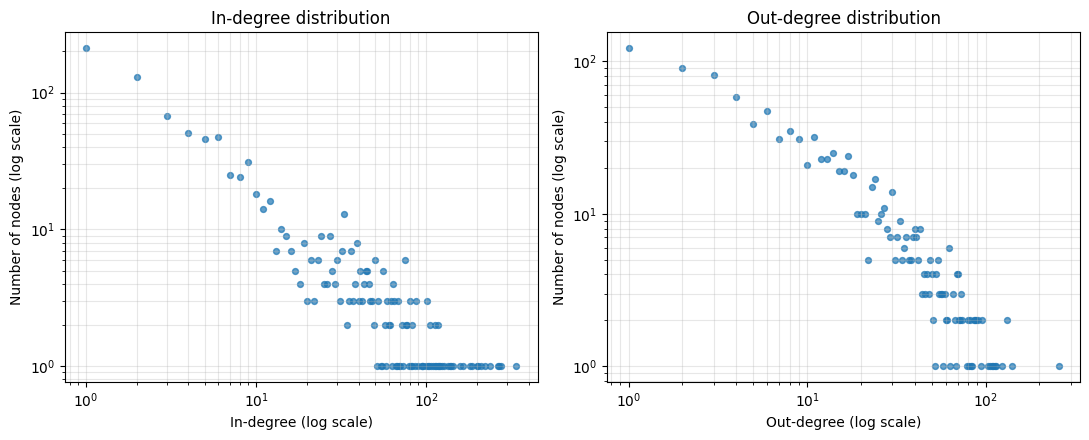

In [7]:
# ---- A.6: Degree distribution figure (log-log scale) ----
# Log-log scale is used because hyperlink networks typically follow a
# power-law-like degree distribution — a log-log plot makes this pattern
# visible as roughly a straight line, unlike a linear-scale plot.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, degrees, title in zip(axes, [in_degrees, out_degrees], ["In-degree", "Out-degree"]):
    degrees_arr = np.array(degrees)
    degrees_arr = degrees_arr[degrees_arr > 0]
    vals, counts = np.unique(degrees_arr, return_counts=True)
    ax.scatter(vals, counts, s=18, alpha=0.7)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(f"{title} (log scale)"); ax.set_ylabel("Number of nodes (log scale)")
    ax.set_title(f"{title} distribution")
    ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/degree_distribution.png", dpi=140)
plt.show()


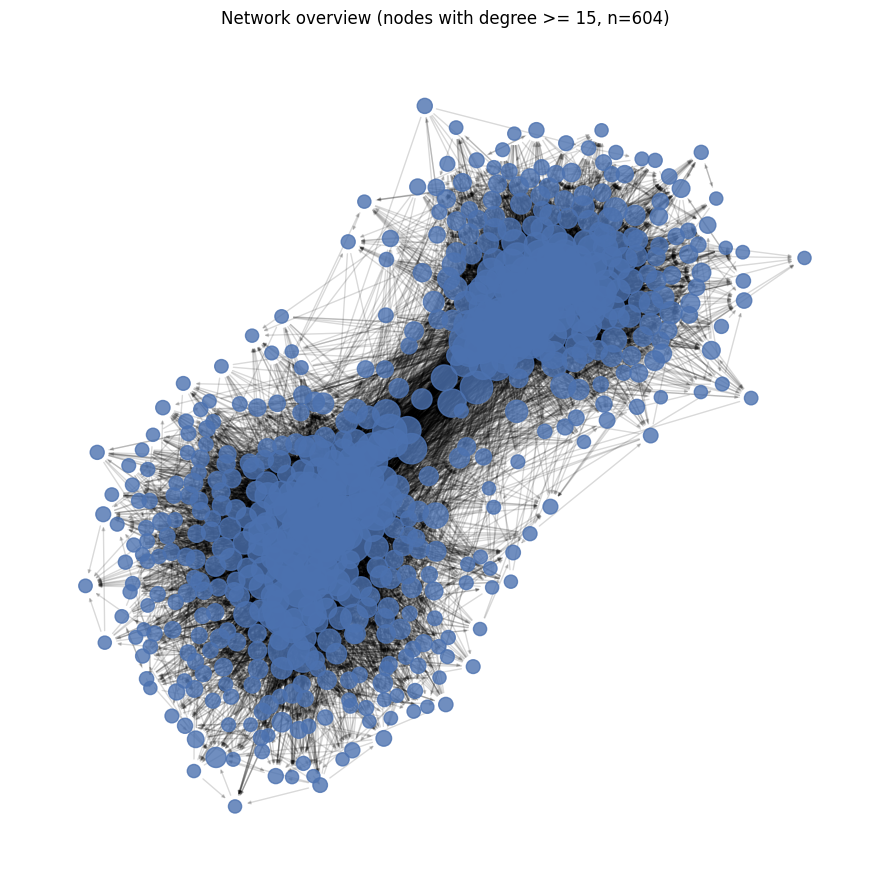

In [8]:
# ---- A.7: Network visualization ----
# NOTE: Sampling/filtering is allowed ONLY for visualization (not for
# calculations). We show only "hub" nodes (degree >= 15) so the plot stays readable.
degrees_all = dict(G_analysis.degree())
nodes_to_show = [n for n, d in degrees_all.items() if d >= 15]
G_sub = G_analysis.subgraph(nodes_to_show)

pos = nx.spring_layout(G_sub, seed=GLOBAL_SEED, k=0.3)
fig, ax = plt.subplots(figsize=(9, 9))
sizes = [30 + 4 * degrees_all[n] for n in G_sub.nodes()]
nx.draw_networkx_nodes(G_sub, pos, node_size=sizes, node_color="#4C72B0", alpha=0.8, ax=ax)
nx.draw_networkx_edges(G_sub, pos, alpha=0.15, arrows=True, arrowsize=5, ax=ax)
ax.set_title(f"Network overview (nodes with degree >= 15, n={G_sub.number_of_nodes()})")
ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/figures/network_overview.png", dpi=140)
plt.show()


### Part A — Interpretation

- The graph shrank from **1490 → 1222 nodes** after preprocessing (266
  isolates and 2 self-loops removed, followed by dropping one small
  2-node disconnected component that remained separate from the giant
  component).
- **Density is very low** (~0.013) — this is typical for social/hyperlink
  networks: each blog links to only a handful of other blogs, not to all
  1222.
- **In/out-degree distributions are heavily right-skewed** (median ~3-7,
  but max 337/256) — this is a signal of **homophily and hub structure**:
  a small number of "authority" blogs attract a disproportionate number
  of links (high in-degree), while the bulk of blogs give/receive only a
  few links. In terms of information flow, this indicates that a small
  set of central voices dominate the network.
- **420 strongly connected components** (versus only 1 weakly connected
  component) — this shows that mutual (bidirectional) linking is rare;
  most links are one-directional (e.g. a small blog links to a large
  blog, but not vice versa). This is an indicator of a hierarchy/
  authority structure rather than a symmetric, friendship-like network.
